  loaded gen 0: 20 models  (df_population_0.pkl)
  loaded gen 1: 20 models  (df_population_1.pkl)
  loaded gen 2: 20 models  (df_population_2.pkl)
  loaded gen 3: 20 models  (df_population_3.pkl)
  loaded gen 4: 20 models  (df_population_4.pkl)
  loaded gen 5: 20 models  (df_population_5.pkl)

Total rows: 120 across generations [0, 1, 2, 3, 4, 5]
Columns: ['Generation', 'Layers', 'Params', 'fp32_train_loss', 'fp32_val_loss', 'fp32_gpu_iou', 'fp32_gpu_fps', 'fp32_ft_train_loss', 'fp32_ft_val_loss', 'fp32_ft_gpu_iou', 'fp32_ft_gpu_fps', 'int8_torch_train_loss', 'int8_torch_val_loss', 'int8_torch_gpu_iou', 'int8_torch_gpu_fps', 'int8_custom_train_loss', 'int8_custom_val_loss', 'int8_custom_gpu_iou', 'int8_custom_gpu_fps', 'GPU_IoU', 'GPU_FPS', 'Fitness', 'Metric', 'FPS', 'gap_fp32_int8_custom', 'gap_fp32ft_int8_custom', 'Gen', 'ModelIdx']
=== Generation 5 (latest) ===


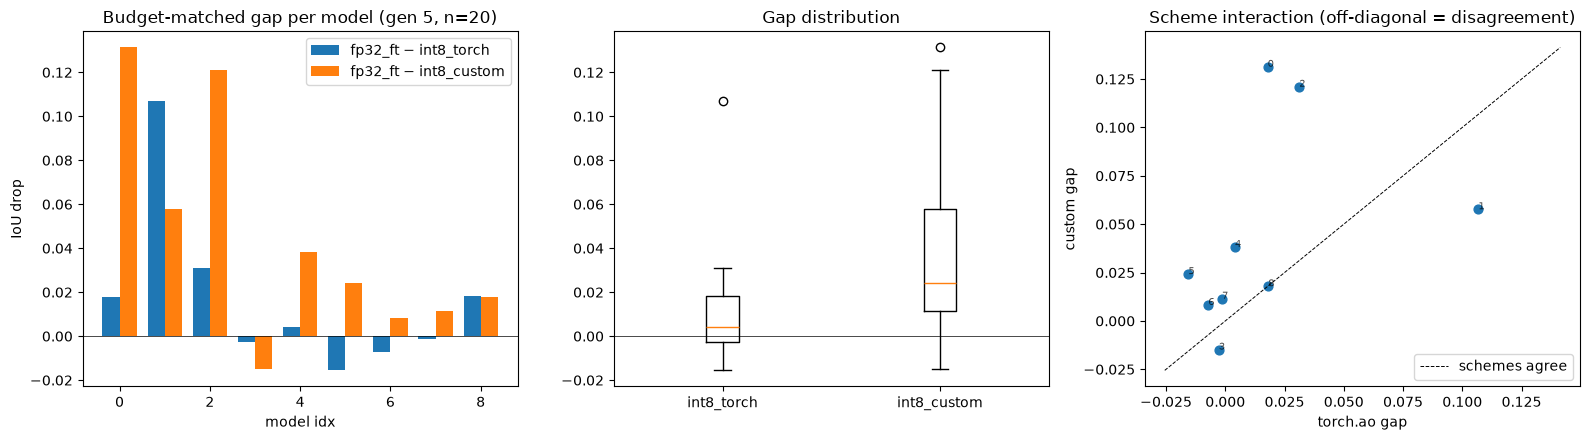

  fp32_ft_gpu_iou − int8_torch   mean=+0.0168 std=0.0368 min=-0.0155 max=+0.1068
  fp32_ft_gpu_iou − int8_custom  mean=+0.0439 std=0.0508 min=-0.0148 max=+0.1313
pair                                           kendall tau   spearman    n
     fp32_ft_gpu_iou vs int8_custom_gpu_iou           0.389      0.533    9
     fp32_ft_gpu_iou vs int8_torch_gpu_iou            0.611      0.750    9
        fp32_gpu_iou vs int8_custom_gpu_iou           0.167      0.200    9
  int8_torch_gpu_iou vs int8_custom_gpu_iou           0.444      0.667    9
  top-3 overlap fp32_ft_gpu_iou vs int8_custom_gpu_iou: 2/3  ([4, 6, 7] vs [3, 6, 7])
  top-3 overlap fp32_ft_gpu_iou vs int8_torch_gpu_iou: 2/3  ([4, 6, 7] vs [4, 5, 6])
  top-3 overlap fp32_gpu_iou vs int8_custom_gpu_iou: 1/3  ([3, 5, 8] vs [3, 6, 7])
  top-3 overlap int8_torch_gpu_iou vs int8_custom_gpu_iou: 1/3  ([4, 5, 6] vs [3, 6, 7])


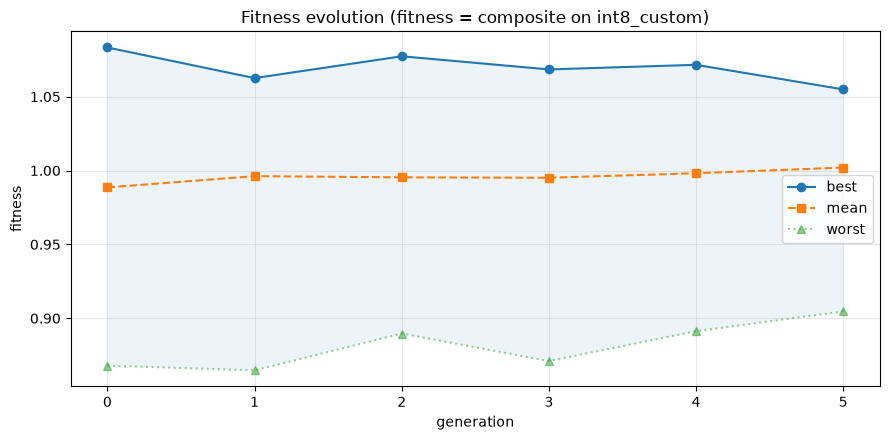

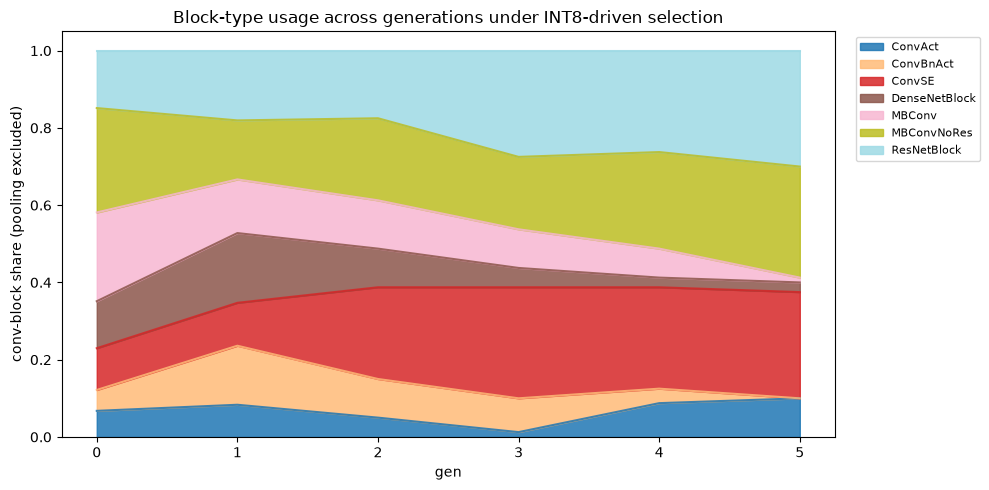


=== gen 5 model 6 — fitness 1.0549 ===
  params: 1,356,796
  fp32         IoU=0.7693
  int8_torch   IoU=0.8703
  int8_custom  IoU=0.8549
  gap fp32->int8_custom = -0.0856
  architecture:
     0. ConvAct          {'out_channels_coefficient': 11, 'kernel_size': '5', 'stride': '1', 'padding': '2', 'activation': 'ReLU'}
     1. AvgPool          {}
     2. ResNetBlock      {'reduction_factor': '2', 'activation': 'ReLU'}
     3. AvgPool          {}
     4. MBConvNoRes      {'expansion_factor': '4', 'activation': 'ReLU'}
     5. AvgPool          {}
     6. ConvSE           {'out_channels_coefficient': 5, 'kernel_size': '5', 'stride': '1', 'padding': '1', 'activation': 'GELU'}
     7. MaxPool          {}

=== gen 5 model 3 — fitness 1.0522 ===
  params: 1,613,539
  fp32         IoU=0.8663
  int8_torch   IoU=0.8400
  int8_custom  IoU=0.8522
  gap fp32->int8_custom = +0.0141
  architecture:
     0. ConvSE           {'out_channels_coefficient': 12, 'kernel_size': '5', 'stride': '1', 'padding': '

In [1]:
# %% [markdown]
# # PyNAS Run Analysis — Generation Results Explorer
#
# Loads `df_population_*.pkl` / `population_*.pkl` from `models_traced/src/`
# and produces the core analysis views for the quantization-robustness study:
#
# 1. Per-generation results tables (fp32 / int8_torch / int8_custom side by side)
# 2. Quantization-gap analysis (the paper's motivating figure)
# 3. Ranking agreement between precisions (Kendall tau — misranking evidence)
# 4. Fitness evolution across generations
# 5. Block-usage evolution (what does INT8-driven selection favor?)

# %%
import sys, os, json, glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))   # notebook lives in notebooks/

pd.set_option("display.max_colwidth", 40)
pd.set_option("display.width", 200)

SRC_DIR = Path("../models_traced/src")      # adjust if your notebook sits elsewhere

# %% [markdown]
# ## 1. Discover and load all completed generations

# %%
def load_all_generations(src_dir: Path = SRC_DIR):
    """Load every df_population_<g>.pkl into one long dataframe with a Gen column."""
    frames = {}
    for p in sorted(src_dir.glob("df_population_*.pkl")):
        try:
            g = int(p.stem.split("_")[-1])
        except ValueError:
            continue
        try:
            df = pd.read_pickle(p)
            df = df.copy()
            df["Gen"] = g
            df["ModelIdx"] = df.index
            frames[g] = df
            print(f"  loaded gen {g}: {len(df)} models  ({p.name})")
        except Exception as e:
            print(f"  FAILED {p.name}: {e}")
    if not frames:
        raise FileNotFoundError(f"No df_population_*.pkl found in {src_dir.resolve()}")
    return frames

gen_frames = load_all_generations()
all_df = pd.concat(gen_frames.values(), ignore_index=True)
print(f"\nTotal rows: {len(all_df)} across generations {sorted(gen_frames)}")
print(f"Columns: {list(all_df.columns)}")

# %% [markdown]
# ## 2. Per-generation results table

# %%
PRECISIONS = ["fp32", "int8_torch", "int8_custom"]

def results_table(gen: int) -> pd.DataFrame:
    """Compact per-model view for one generation."""
    df = gen_frames[gen]
    cols = ["ModelIdx", "Params"]
    for p in PRECISIONS:
        c = f"{p}_gpu_iou"
        if c in df.columns:
            cols.append(c)
    for extra in ["gap_fp32_int8_custom", "Fitness", "FPS"]:
        if extra in df.columns:
            cols.append(extra)
    out = df[cols].copy()
    # sort by fitness descending so the GA's favorites are on top
    if "Fitness" in out.columns:
        out = out.sort_values("Fitness", ascending=False)
    return out.round(4)

latest_gen = max(gen_frames)
print(f"=== Generation {latest_gen} (latest) ===")
results_table(latest_gen)

# %% [markdown]
# ## 3. Quantization-gap analysis — the motivating figure
#
# Per-architecture drop from FP32 to each INT8 scheme. Architecture-dependent
# spread here is the evidence that quantization robustness is an architectural
# property the GA can select for.

# %%
def gap_analysis_bm(df, title=""):
    """Budget-matched gaps: fp32_ft baseline (falls back to fp32 if absent)."""
    base = "fp32_ft_gpu_iou" if "fp32_ft_gpu_iou" in df.columns else "fp32_gpu_iou"
    d = df.dropna(subset=[base]).copy()
    d = d[d[base] > 0]
    gaps = {p: d[base] - d[f"{p}_gpu_iou"]
            for p in ["int8_torch", "int8_custom"] if f"{p}_gpu_iou" in d.columns}

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    x = np.arange(len(d)); w = 0.38
    for i, (p, g) in enumerate(gaps.items()):
        axes[0].bar(x + (i - .5) * w, g.values, w, label=f"{base.split('_gpu')[0]} − {p}")
    axes[0].axhline(0, color="k", lw=.5); axes[0].legend()
    axes[0].set_title(f"Budget-matched gap per model {title}")
    axes[0].set_xlabel("model idx"); axes[0].set_ylabel("IoU drop")

    axes[1].boxplot([g.dropna().values for g in gaps.values()],
                    tick_labels=list(gaps.keys()))
    axes[1].axhline(0, color="k", lw=.5); axes[1].set_title("Gap distribution")

    # the scheme-interaction scatter: one point per architecture
    if len(gaps) == 2:
        gt, gc = gaps["int8_torch"], gaps["int8_custom"]
        axes[2].scatter(gt, gc, s=40)
        lim = [min(gt.min(), gc.min()) - .01, max(gt.max(), gc.max()) + .01]
        axes[2].plot(lim, lim, "k--", lw=.7, label="schemes agree")
        for i_, (a, b) in enumerate(zip(gt, gc)):
            axes[2].annotate(str(d.index[i_]), (a, b), fontsize=7, alpha=.7)
        axes[2].set_xlabel("torch.ao gap"); axes[2].set_ylabel("custom gap")
        axes[2].set_title("Scheme interaction (off-diagonal = disagreement)")
        axes[2].legend()
    plt.tight_layout(); plt.show()

    for p, g in gaps.items():
        g = g.dropna()
        print(f"  {base} − {p:<12} mean={g.mean():+.4f} std={g.std():.4f} "
              f"min={g.min():+.4f} max={g.max():+.4f}")

gap_analysis_bm(gen_frames[latest_gen], f"(gen {latest_gen}, n={len(gen_frames[latest_gen])})")

# %% [markdown]
# ## 4. Ranking agreement — does the precision choice reorder architectures?
#
# Kendall tau between architecture rankings under different precisions.
# tau < ~0.9 means the search objective choice materially changes which
# architectures win — the core misranking claim.

# %%
from scipy.stats import kendalltau, spearmanr

def ranking_agreement(df: pd.DataFrame):
    pairs = [
        ("fp32_ft_gpu_iou", "int8_custom_gpu_iou"),   # the honest misranking claim
        ("fp32_ft_gpu_iou", "int8_torch_gpu_iou"),
        ("fp32_gpu_iou",    "int8_custom_gpu_iou"),   # naive, for comparison
        ("int8_torch_gpu_iou", "int8_custom_gpu_iou"),
    ]
    print(f"{'pair':<45} {'kendall tau':>12} {'spearman':>10} {'n':>4}")
    for a, b in pairs:
        if a not in df.columns or b not in df.columns:
            continue
        d = df[[a, b]].dropna()
        d = d[(d[a] > 0) & (d[b] > 0)]
        if len(d) < 3:
            print(f"{a} vs {b}: insufficient data ({len(d)})")
            continue
        kt = kendalltau(d[a], d[b])
        sp = spearmanr(d[a], d[b])
        print(f"{a:>20} vs {b:<22} {kt.statistic:>12.3f} {sp.statistic:>10.3f} {len(d):>4}")

    # top-3 agreement (elitism-relevant)
    for a, b in pairs:
        if a not in df.columns or b not in df.columns:
            continue
        d = df[[a, b]].dropna()
        if len(d) < 3:
            continue
        top_a = set(d.nlargest(3, a).index)
        top_b = set(d.nlargest(3, b).index)
        print(f"  top-3 overlap {a} vs {b}: {len(top_a & top_b)}/3  "
              f"({sorted(top_a)} vs {sorted(top_b)})")

ranking_agreement(gen_frames[latest_gen])

# %% [markdown]
# ## 5. Fitness evolution across generations

# %%
def fitness_evolution():
    stats = []
    for g in sorted(gen_frames):
        df = gen_frames[g]
        if "Fitness" not in df.columns:
            continue
        f = pd.to_numeric(df["Fitness"], errors="coerce").dropna()
        f = f[f > 0]
        if len(f) == 0:
            continue
        stats.append({"gen": g, "best": f.max(), "mean": f.mean(),
                      "median": f.median(), "worst": f.min(), "n": len(f)})
    s = pd.DataFrame(stats)
    if s.empty:
        print("No fitness data yet")
        return s

    plt.figure(figsize=(9, 4.5))
    plt.plot(s.gen, s.best, "o-", label="best")
    plt.plot(s.gen, s["mean"], "s--", label="mean")
    plt.plot(s.gen, s.worst, "^:", label="worst", alpha=0.5)
    plt.fill_between(s.gen, s.worst, s.best, alpha=0.08)
    plt.xlabel("generation"); plt.ylabel("fitness")
    plt.title("Fitness evolution (fitness = composite on int8_custom)")
    plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    return s

fitness_evolution()

# %% [markdown]
# ## 6. Block-usage evolution — what does INT8 selection favor?
#
# Parses the Layers JSON per model and tracks conv-block share per generation.
# If certain blocks (e.g. Sigmoid-gated ConvSE) die out under int8_custom-driven
# selection, that is a headline result.

# %%
def block_usage_evolution():
    POOLING = {"AvgPool", "MaxPool"}
    rows = []
    for g in sorted(gen_frames):
        df = gen_frames[g]
        if "Layers" not in df.columns:
            continue
        from collections import Counter
        counter = Counter()
        for s in df["Layers"].dropna():
            try:
                layers = json.loads(s) if isinstance(s, str) else s
            except Exception:
                continue
            for layer in layers:
                lt = layer.get("layer_type", "?") if isinstance(layer, dict) else str(layer)
                if lt not in POOLING:
                    counter[lt] += 1
        total = sum(counter.values()) or 1
        for bt, c in counter.items():
            rows.append({"gen": g, "block": bt, "share": c / total})

    u = pd.DataFrame(rows)
    if u.empty:
        print("No layer data")
        return u

    pivot = u.pivot_table(index="gen", columns="block", values="share", fill_value=0)
    pivot.plot(kind="area", stacked=True, figsize=(10, 5), alpha=0.85, cmap="tab20")
    plt.ylabel("conv-block share (pooling excluded)")
    plt.title("Block-type usage across generations under INT8-driven selection")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    plt.tight_layout(); plt.show()
    return pivot.round(3)

block_usage_evolution()

# %% [markdown]
# ## 7. Best architecture inspector

# %%
def show_best(gen: int, k: int = 3):
    df = gen_frames[gen]
    if "Fitness" not in df.columns:
        print("no fitness column"); return
    top = df.nlargest(k, "Fitness")
    for _, row in top.iterrows():
        print(f"\n=== gen {gen} model {int(row['ModelIdx'])} — fitness {row['Fitness']:.4f} ===")
        print(f"  params: {row.get('Params', '?'):,}" if pd.notna(row.get('Params')) else "  params: ?")
        for p in PRECISIONS:
            c = f"{p}_gpu_iou"
            if c in row and pd.notna(row[c]):
                print(f"  {p:<12} IoU={row[c]:.4f}")
        if "gap_fp32_int8_custom" in row and pd.notna(row["gap_fp32_int8_custom"]):
            print(f"  gap fp32->int8_custom = {row['gap_fp32_int8_custom']:+.4f}")
        try:
            layers = json.loads(row["Layers"])
            print("  architecture:")
            for i, layer in enumerate(layers):
                lt = layer.get("layer_type", "?")
                extras = {k: v for k, v in layer.items() if k != "layer_type"}
                print(f"    {i:2d}. {lt:<16} {extras}")
        except Exception:
            print(f"  layers: {str(row.get('Layers'))[:120]}")

show_best(latest_gen, k=3)

# %% [markdown]
# ## 8. (Optional) Load full population objects
#
# The population pickles contain the actual Individual objects — needed only
# if you want to rebuild a model (`pop.build_model(ind.parsed_layers)`) or
# inspect genomes directly. Requires the pynas package importable.

# %%
def load_population_objects(gen: int):
    import pickle
    p = SRC_DIR / f"population_{gen}.pkl"
    with open(p, "rb") as f:
        return pickle.load(f)

# individuals = load_population_objects(latest_gen)
# print(len(individuals), "individuals;", individuals[0].architecture)

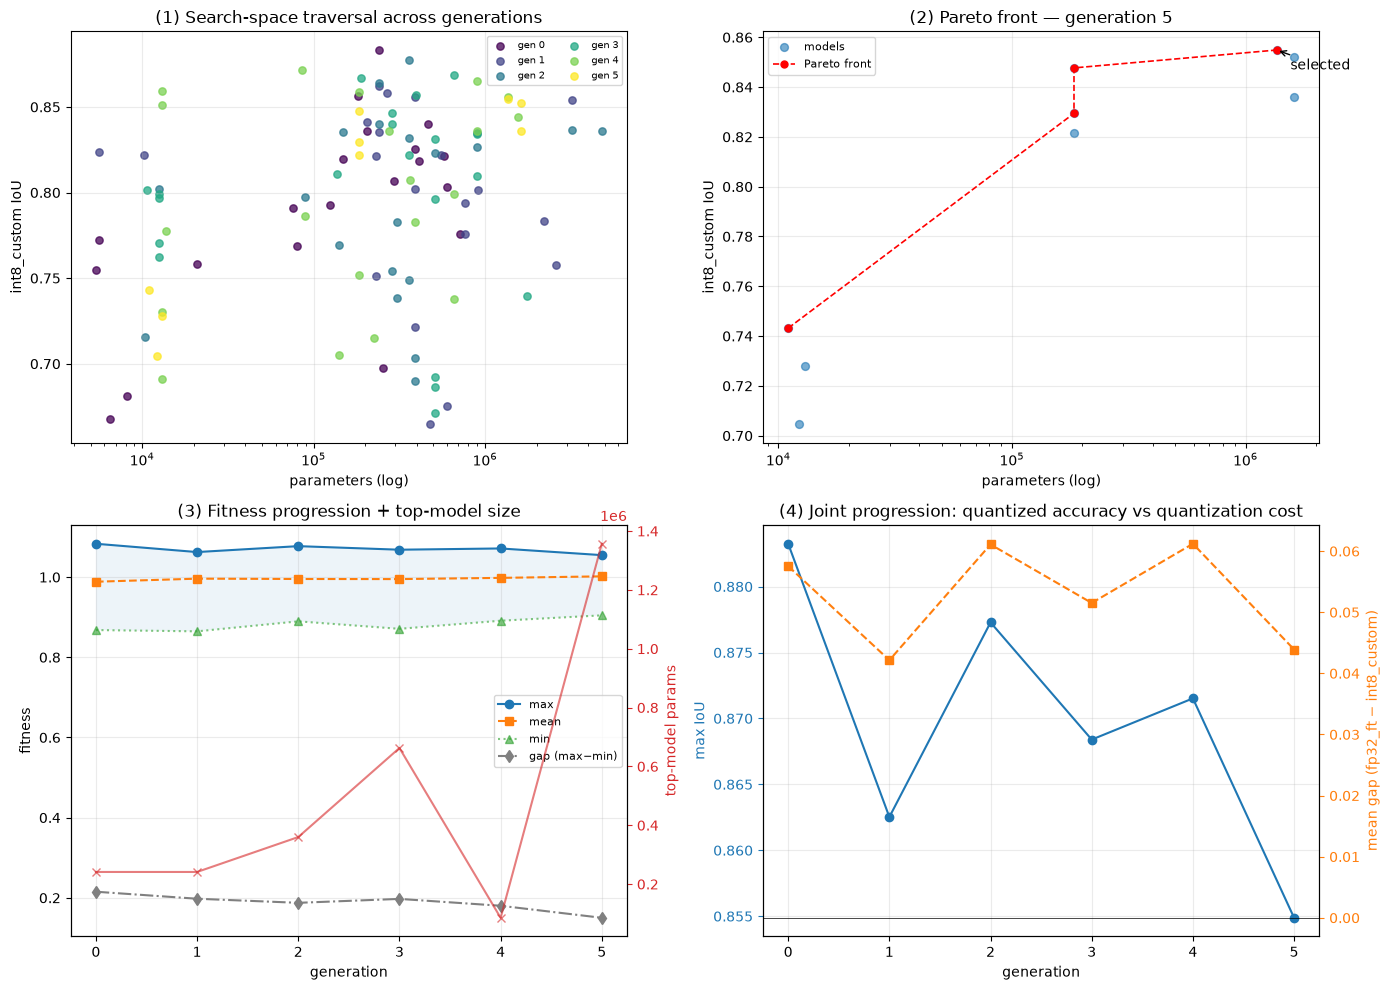

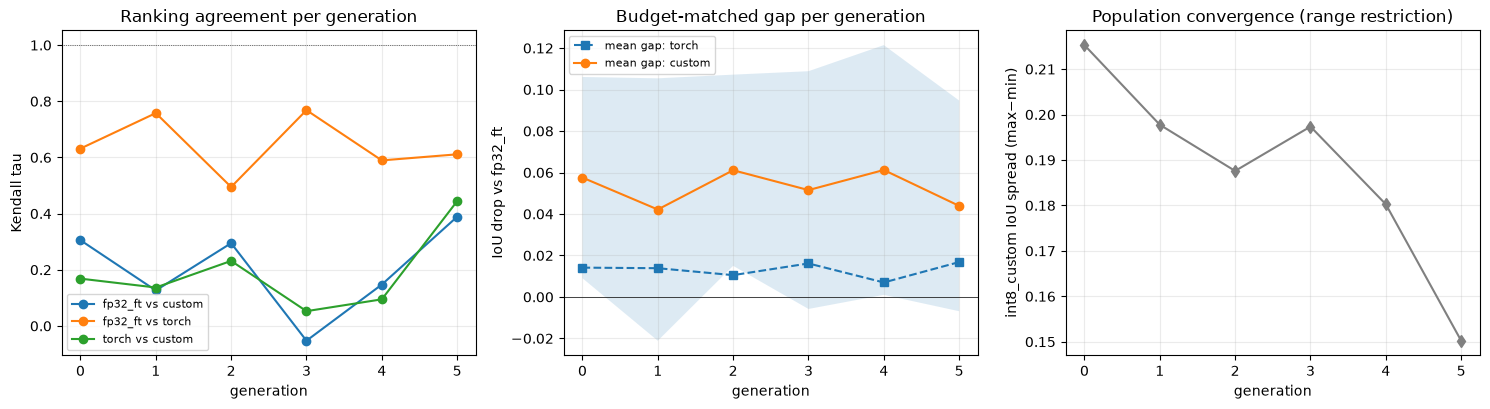

,gen,n,tau_ft_custom,tau_ft_torch,tau_torch_custom,gap_torch_mean,gap_custom_mean,gap_custom_std,iou_spread
0,0,20,0.3053,0.6316,0.1684,0.0141,0.0575,0.0485,0.2153
1,1,20,0.1263,0.7579,0.1368,0.0138,0.0422,0.0633,0.1978
2,2,20,0.2947,0.4947,0.2316,0.0105,0.0611,0.0461,0.1876
3,3,20,-0.0526,0.7684,0.0526,0.0161,0.0515,0.0573,0.1974
4,4,20,0.1474,0.5895,0.0947,0.0070,0.0612,0.0602,0.1803
5,5,9,0.3889,0.6111,0.4444,0.0168,0.0439,0.0508,0.1502


In [2]:
# %% [markdown]
# ## Figure-3-style cross-generation summary (paper layout, quant-robustness version)
#
# Mirrors Fig. 3 of Del Prete et al. (Sci Rep 2025), adapted:
#   (1) IoU vs Params scatter, colored by generation (search-space traversal)
#   (2) Pareto front of the latest generation (int8_custom IoU vs Params)
#   (3) Fitness progression: max / mean / min + fitness gap + top-model params
#   (4) Joint trajectory: max int8_custom IoU and mean budget-matched gap
# Plus: per-generation Kendall-tau trend (ranking agreement under convergence).

# %%
from scipy.stats import kendalltau

BASE = "fp32_ft_gpu_iou"      # budget-matched baseline
TARGET = "int8_custom_gpu_iou"
TORCH = "int8_torch_gpu_iou"

def _valid(df, cols):
    d = df.dropna(subset=[c for c in cols if c in df.columns]).copy()
    for c in cols:
        if c in d.columns:
            d = d[d[c] > 0]
    return d

def figure3_style(gen_frames):
    gens = sorted(gen_frames)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # ---- (1) IoU vs Params, colored by generation ----
    ax = axes[0, 0]
    cmap = plt.cm.viridis
    for g in gens:
        d = _valid(gen_frames[g], [TARGET, "Params"])
        ax.scatter(d["Params"], d[TARGET], s=28, alpha=0.75,
                   color=cmap(g / max(gens) if max(gens) else 0.5),
                   label=f"gen {g}")
    ax.set_xscale("log")
    ax.set_xlabel("parameters (log)")
    ax.set_ylabel("int8_custom IoU")
    ax.set_title("(1) Search-space traversal across generations")
    ax.legend(fontsize=7, ncol=2)
    ax.grid(alpha=0.25)

    # ---- (2) Pareto front, latest generation ----
    ax = axes[0, 1]
    gl = gens[-1]
    d = _valid(gen_frames[gl], [TARGET, "Params"]).sort_values("Params")
    ax.scatter(d["Params"], d[TARGET], s=32, alpha=0.6, label="models")
    # Pareto: fewer params AND higher IoU
    pareto, best = [], -np.inf
    for _, row in d.iterrows():
        if row[TARGET] > best:
            pareto.append(row); best = row[TARGET]
    if pareto:
        pf = pd.DataFrame(pareto)
        ax.plot(pf["Params"], pf[TARGET], "r--o", ms=5, lw=1.2, label="Pareto front")
        star = pf.iloc[pf[TARGET].idxmax() if len(pf) == 1 else -1]
        ax.annotate("selected", (star["Params"], star[TARGET]),
                    xytext=(10, -14), textcoords="offset points",
                    arrowprops=dict(arrowstyle="->", lw=1))
    ax.set_xscale("log")
    ax.set_xlabel("parameters (log)")
    ax.set_ylabel("int8_custom IoU")
    ax.set_title(f"(2) Pareto front — generation {gl}")
    ax.legend(fontsize=8); ax.grid(alpha=0.25)

    # ---- (3) Fitness progression + top-model params ----
    ax = axes[1, 0]
    rows = []
    for g in gens:
        df = gen_frames[g]
        f = pd.to_numeric(df.get("Fitness"), errors="coerce").dropna()
        f = f[f > 0]
        if len(f) == 0:
            continue
        top_idx = f.idxmax()
        rows.append({"gen": g, "max": f.max(), "mean": f.mean(), "min": f.min(),
                     "gap": f.max() - f.min(),
                     "top_params": df.loc[top_idx, "Params"]})
    s = pd.DataFrame(rows)
    ax.plot(s.gen, s["max"], "o-", label="max")
    ax.plot(s.gen, s["mean"], "s--", label="mean")
    ax.plot(s.gen, s["min"], "^:", label="min", alpha=0.6)
    ax.fill_between(s.gen, s["min"], s["max"], alpha=0.08)
    ax.plot(s.gen, s["gap"], "d-.", color="gray", label="gap (max−min)")
    ax.set_xlabel("generation"); ax.set_ylabel("fitness")
    ax2 = ax.twinx()
    ax2.plot(s.gen, s["top_params"], "x-", color="tab:red", alpha=0.6)
    ax2.set_ylabel("top-model params", color="tab:red")
    ax2.tick_params(axis="y", colors="tab:red")
    ax.set_title("(3) Fitness progression + top-model size")
    ax.legend(fontsize=8, loc="center right"); ax.grid(alpha=0.25)

    # ---- (4) Joint trajectory: max IoU + mean budget-matched gap ----
    ax = axes[1, 1]
    rows = []
    for g in gens:
        df = gen_frames[g]
        d = _valid(df, [TARGET])
        if len(d) == 0:
            continue
        row = {"gen": g, "max_iou": d[TARGET].max()}
        db = _valid(df, [BASE, TARGET])
        if len(db) > 0:
            row["mean_gap"] = (db[BASE] - db[TARGET]).mean()
        rows.append(row)
    t = pd.DataFrame(rows)
    ax.plot(t.gen, t.max_iou, "o-", color="tab:blue", label="max int8_custom IoU")
    ax.set_xlabel("generation"); ax.set_ylabel("max IoU", color="tab:blue")
    ax.tick_params(axis="y", colors="tab:blue")
    if "mean_gap" in t.columns:
        ax3 = ax.twinx()
        ax3.plot(t.gen, t.mean_gap, "s--", color="tab:orange",
                 label="mean budget-matched gap")
        ax3.axhline(0, color="k", lw=0.5)
        ax3.set_ylabel("mean gap (fp32_ft − int8_custom)", color="tab:orange")
        ax3.tick_params(axis="y", colors="tab:orange")
    ax.set_title("(4) Joint progression: quantized accuracy vs quantization cost")
    ax.grid(alpha=0.25)

    plt.tight_layout(); plt.show()
    return s

fig3_stats = figure3_style(gen_frames)
fig3_stats

# %% [markdown]
# ## Per-generation ranking agreement + gap trend
# NOTE: later generations are converged populations — tau there is deflated by
# restriction of range. Gen 0 (diverse random population) is the clean
# misranking estimate; the trend shows agreement under convergence.

# %%
def per_generation_trends(gen_frames):
    rows = []
    for g in sorted(gen_frames):
        df = gen_frames[g]
        d = _valid(df, [BASE, TARGET, TORCH])
        row = {"gen": g, "n": len(d)}
        if len(d) >= 4:
            row["tau_ft_custom"] = kendalltau(d[BASE], d[TARGET]).statistic
            row["tau_ft_torch"] = kendalltau(d[BASE], d[TORCH]).statistic
            row["tau_torch_custom"] = kendalltau(d[TORCH], d[TARGET]).statistic
        if len(d) > 0:
            row["gap_torch_mean"] = (d[BASE] - d[TORCH]).mean()
            row["gap_custom_mean"] = (d[BASE] - d[TARGET]).mean()
            row["gap_custom_std"] = (d[BASE] - d[TARGET]).std()
            row["iou_spread"] = d[TARGET].max() - d[TARGET].min()
        rows.append(row)
    t = pd.DataFrame(rows)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    ax = axes[0]
    for c, lbl in [("tau_ft_custom", "fp32_ft vs custom"),
                   ("tau_ft_torch", "fp32_ft vs torch"),
                   ("tau_torch_custom", "torch vs custom")]:
        if c in t.columns:
            ax.plot(t.gen, t[c], "o-", label=lbl)
    ax.axhline(1.0, color="k", lw=0.5, ls=":")
    ax.set_xlabel("generation"); ax.set_ylabel("Kendall tau")
    ax.set_title("Ranking agreement per generation"); ax.legend(fontsize=8)
    ax.grid(alpha=0.25)

    ax = axes[1]
    ax.plot(t.gen, t.gap_torch_mean, "s--", label="mean gap: torch")
    ax.plot(t.gen, t.gap_custom_mean, "o-", label="mean gap: custom")
    ax.fill_between(t.gen,
                    t.gap_custom_mean - t.gap_custom_std,
                    t.gap_custom_mean + t.gap_custom_std, alpha=0.15)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_xlabel("generation"); ax.set_ylabel("IoU drop vs fp32_ft")
    ax.set_title("Budget-matched gap per generation"); ax.legend(fontsize=8)
    ax.grid(alpha=0.25)

    ax = axes[2]
    ax.plot(t.gen, t.iou_spread, "d-", color="gray")
    ax.set_xlabel("generation"); ax.set_ylabel("int8_custom IoU spread (max−min)")
    ax.set_title("Population convergence (range restriction)")
    ax.grid(alpha=0.25)

    plt.tight_layout(); plt.show()
    return t.round(4)

per_generation_trends(gen_frames)